# Problem Title - Exploration
Issue: #<issue-number>

## 1. Setup and Imports
Import pandas, matplotlib, and seaborn, then configure clean plotting defaults once.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load and Inspect Data
Load dataset.csv and quickly check shape, column types, missing values, and sample rows.

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/iiitl/Linear-Regression/main/dataset.csv')
#Basic Inspection of dataset
print("Shape of dataset:")
print(df.shape)
df.head()

Shape of dataset:
(1030, 9)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
print("Column names and data types:")
print(df.dtypes)
print("Basic statistics for each column:")
df.describe()


Column names and data types:
Cement                           float64
Blast Furnace Slag               float64
Fly Ash                          float64
Water                            float64
Superplasticizer                 float64
Coarse Aggregate                 float64
Fine Aggregate                   float64
Age                                int64
Concrete compressive strength    float64
dtype: object
Basic statistics for each column:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64


## 3. EDA (Distributions and Correlations)
Analyze feature distributions, outliers, and correlations that affect modeling decisions.

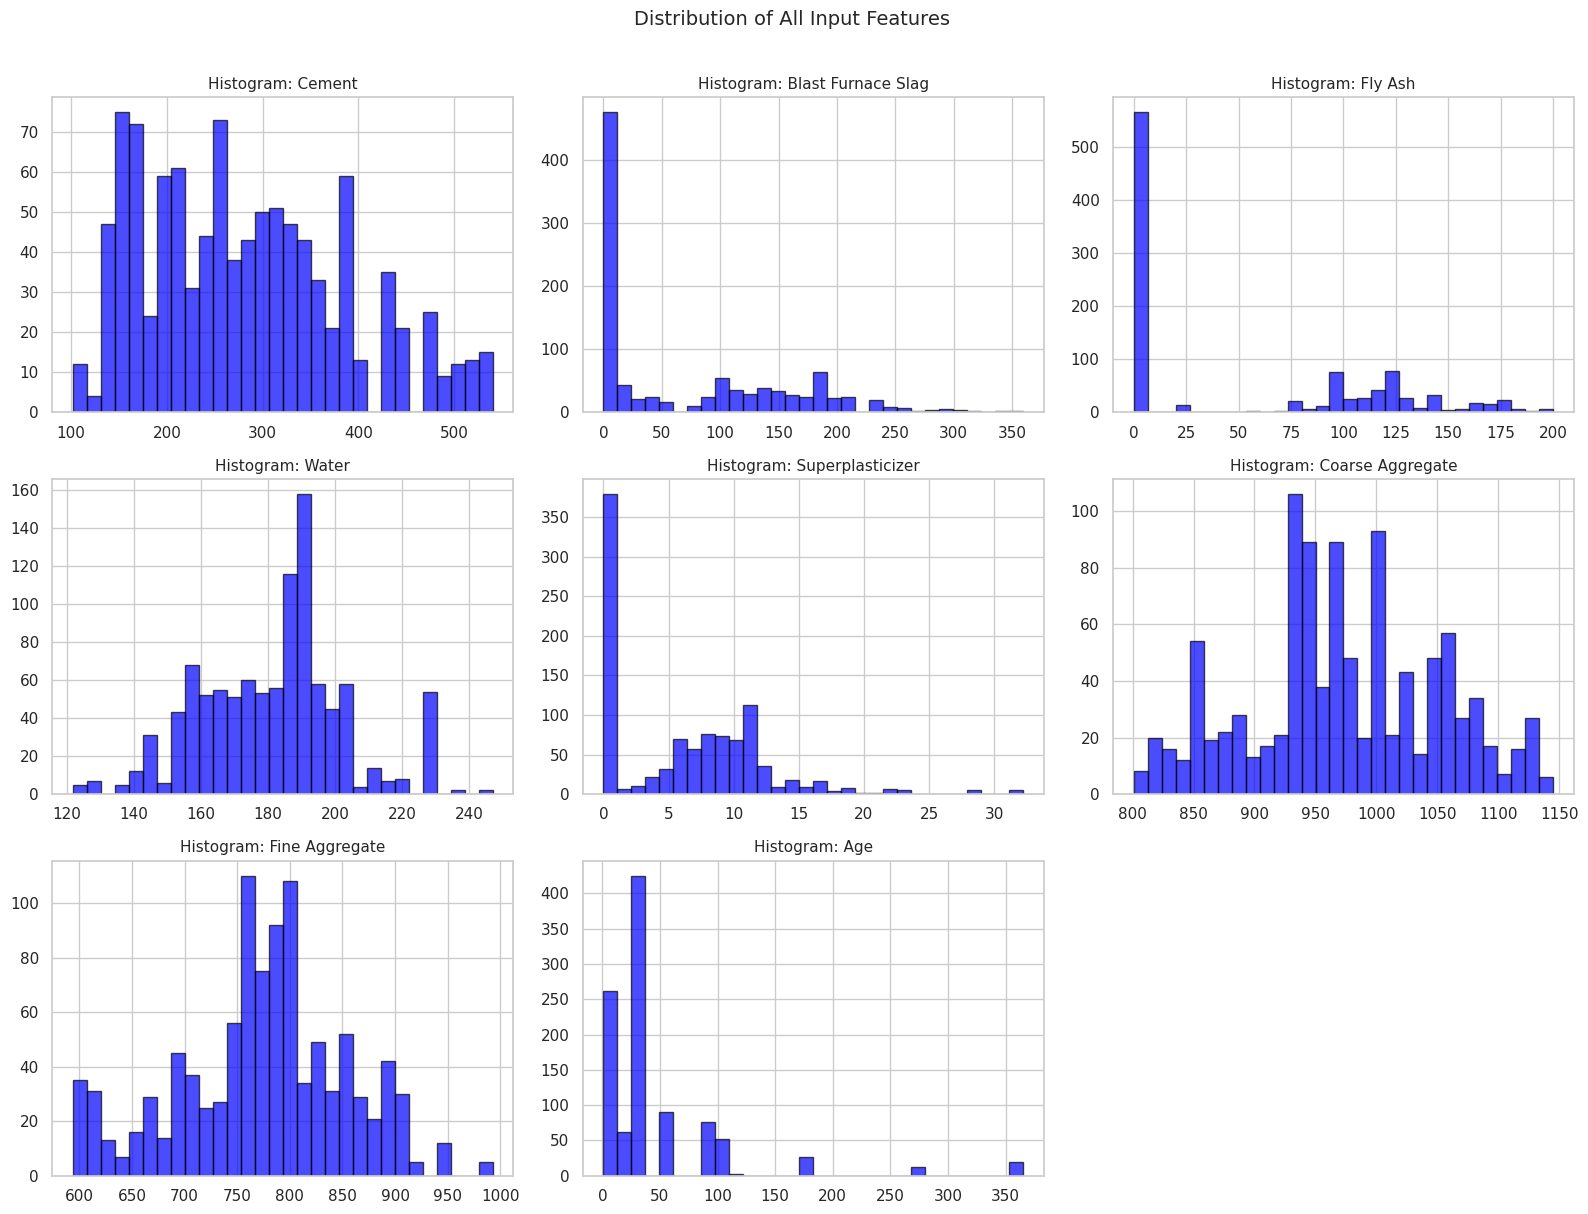

In [ ]:
input_features = df.columns[:-1]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
#convert axes to 1D array
axes=axes.flatten()
for i, col in enumerate(input_features):
  axes[i].hist(df[col], bins=30, color='blue', edgecolor='black', alpha=0.7)
  axes[i].set_title(f'Histogram: {col}', fontsize=11)
axes[8].set_visible(False)
plt.suptitle('Distribution of All Input Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('histograms.png', bbox_inches='tight')
plt.show()


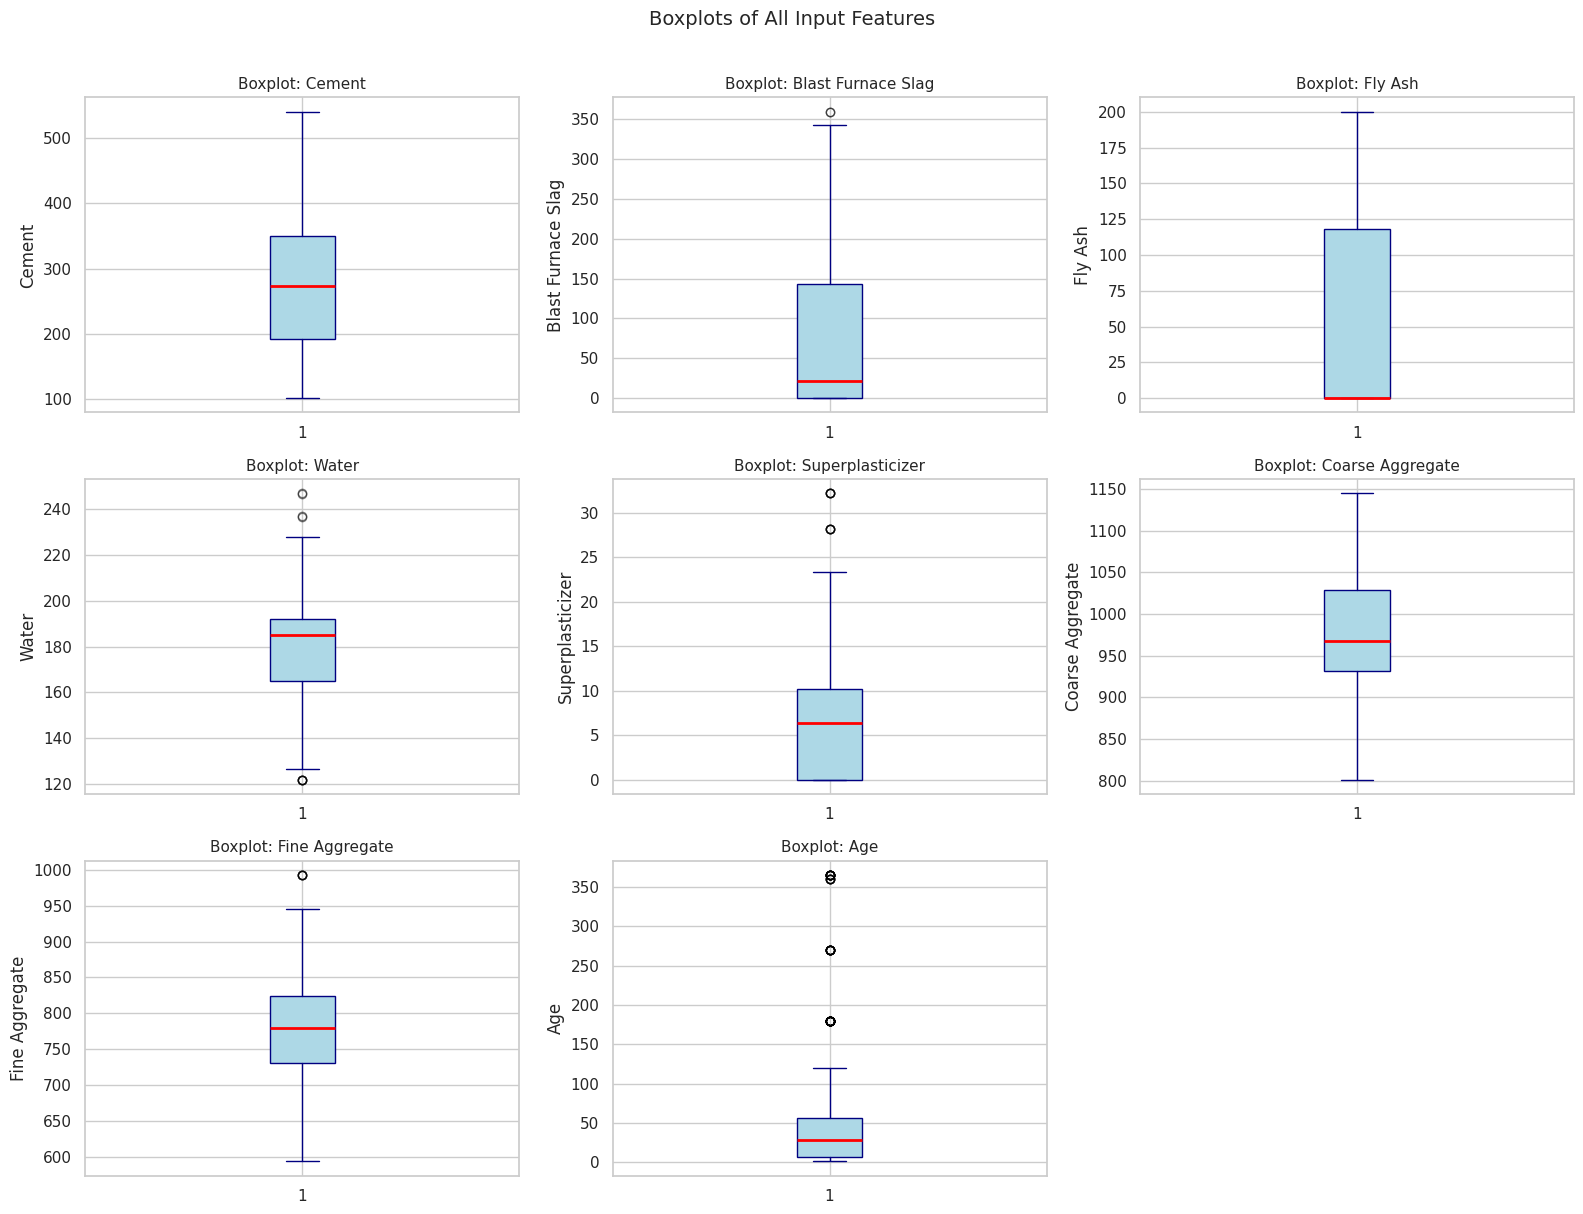

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(input_features):
    axes[i].boxplot(df[col],
                    patch_artist=True,boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'),flierprops=dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_ylabel(col)
axes[8].set_visible(False)
plt.suptitle('Boxplots of All Input Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()


In [ ]:
outlier_counts = {}
skewness = {}
for col in input_features:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_fence = Q1 - 1.5 * IQR
  upper_fence = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
  outlier_counts[col] = len(outliers)
  skewness[col] = df[col].skew()
print("*-" * 25)
print("OUTLIER COUNTS (IQR Method)")
print("*-" * 25)
for col, count in sorted(outlier_counts.items(), key=lambda x: -x[1]):
    print(f"  {col:30s}: {count} outliers")
skew_series = pd.Series(skewness).abs().sort_values(ascending=False)
print("\n" + "=" * 50)
print("TOP 3 FEATURES WITH STRONGEST SKEW")
print("=" * 50)
for col in skew_series.head(3).index:
    direction = "right-skewed (positive)" if skewness[col] > 0 else "left-skewed (negative)"
    print(f"  {col:30s}: {skewness[col]:.4f} → {direction}")


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
OUTLIER COUNTS (IQR Method)
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  Age                           : 59 outliers
  Superplasticizer              : 10 outliers
  Water                         : 9 outliers
  Fine Aggregate                : 5 outliers
  Blast Furnace Slag            : 2 outliers
  Cement                        : 0 outliers
  Fly Ash                       : 0 outliers
  Coarse Aggregate              : 0 outliers

TOP 3 FEATURES WITH STRONGEST SKEW
  Age                           : 3.2692 → right-skewed (positive)
  Superplasticizer              : 0.9072 → right-skewed (positive)
  Blast Furnace Slag            : 0.8007 → right-skewed (positive)


## 4. Visualization (Matplotlib/Seaborn)
Create at least three relevant plots and explain what each one reveals.

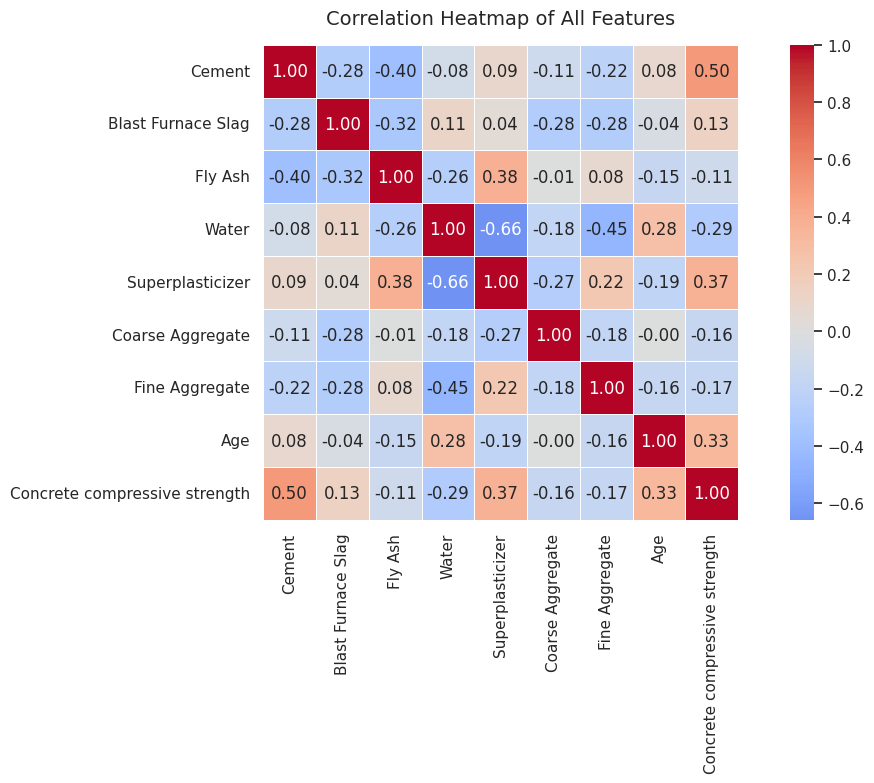


Correlation with target 'Concrete compressive strength':
Concrete compressive strength    1.000000
Cement                           0.497832
Superplasticizer                 0.366079
Age                              0.328873
Blast Furnace Slag               0.134829
Fly Ash                         -0.105755
Coarse Aggregate                -0.164935
Fine Aggregate                  -0.167241
Water                           -0.289633
Name: Concrete compressive strength, dtype: float64


In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidths=0.5,square=True)
plt.title('Correlation Heatmap of All Features', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
target_col = df.columns[-1]
print(f"\nCorrelation with target '{target_col}':")
print(df.corr()[target_col].sort_values(ascending=False))

## 5. Key Observations
Write three to five concise findings linked directly to your EDA and plots.
## Key Observations

1. Cement has the strongest effect on concrete strength out of all ingredients.
   The heatmap shows 0.50 correlation.

2. Water is the only ingredient that actively makes concrete weaker.
   Correlation is -0.29, so as quantity of water is increased,strength keeps on decreasing.
   Interestingly, Water and Superplasticizer are strongly negatively related(-0.66) —
   it looks like when more Superplasticizer is used, less Water is needed.

3. Age was the most surprising part— concrete keeps getting stronger the longer we leave it.
   The correlation with strength is 0.33.

4. Superplasticizer and Fly Ash histograms both have a giant bar at zero.
   A lot of mixes simply didn't use these ingredients at all, which makes
   their distributions look very different from the others.

5. Age has by far the most outliers (59) and the highest skew (3.27).
   Almost every sample was tested at 28 days — the standard curing time —
   and only a handful were tested at 100+ days. That's what's causing the long tail.
   

## 6. Summary
Answer only these exploration-focused questions:
1. What are the top 3 dataset insights from your EDA?
.Cement is the clearest driver of strength — 0.497 correlation, nothing else comes close.
.In case of age,we can observe that Skewness of 3.27 means the data is heavily
bunched around 28 days with just a few samples going up to a year.
.Ash and Superplasticizer both have medians of 0, meaning more than half
the mixes didn't use them at all. They're optional additives, not base ingredients,so seeing this in the data makes sense.
2. Which plot gave the strongest insight, and why?
*****
The heatmap gave me the strongest insight. Looking at individual histograms tells us about one featureat a time, but the heatmap showed me things I wouldn't have noticed otherwise —
like Water and Superplasticizer being negatively correlated (-0.66) with each other,
or Fly Ash and Cement both being negatively correlated, suggesting they substitute for each other in mixes.
*****

3. What data issues or patterns (imbalance, skew, outliers, multicollinearity) did your visualizations reveal?
 - **Skew**: Age (3.27), Superplasticizer (0.91), and Blast Furnace Slag (0.80)
  are all right-skewed. Their histograms show a long tail stretching to the right.
- **Outliers**: Age has 59 outlier points by IQR — the most of any feature.
  Superplasticizer has 10 and Water has 9. The boxplots confirm this visually
  with dots scattered above the upper whisker.
- **Zero inflation**: Fly Ash and Superplasticizer both have Q1 = 0 in the
  describe() output, meaning at least 25% of all samples have zero for these
  features. This isn't missing data — these ingredients just weren't used in
  those particular mixes.


## Preprocessing Recommendations
1. Log-transform Age, Superplasticizer, and Blast Furnace Slag.
   All three are right-skewed and log1p() handles the zero values safely.
   This will make their distributions more normal before fitting the model.
2. Clip outliers in Age using IQR bounds.
   59 outliers is too much. those few samples tested at 360+ days could
   drag the regression line in the wrong direction .
4. Add a presence indicator for Fly Ash and Superplasticizer.
   Because so many rows are zero, a single scaled column doesn't tell the model
   whether the ingredient was absent or just used in a small amount.
   A simple 0/1 column alongside the original fixes that.
